# 01 — EDA: Consumo Doméstico de Café (1990–2020)

**High Garden Coffee** — Reto Técnico ML

Objetivo: entender la calidad y estructura del dataset antes de modelar, y dejar explícitas dos limitaciones importantes del enunciado frente a los datos entregados:

- Las unidades son **tazas**, tal como indica el enunciado del reto.
- El PDF pide identificar **"rangos de precios futuros"**, pero el dataset **no contiene ninguna columna de precio** — solo consumo doméstico. La solución se enfoca en forecasting de **consumo** futuro con intervalos de confianza, y se deja documentado como limitación/roadmap la incorporación de precio desde una fuente externa (ej. ICO Composite Price).

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_prep import build_long_dataset, load_raw
import viz

viz.set_style()
pd.set_option('display.max_columns', 10)

## 1. Vista general del dataset crudo

In [2]:
raw = load_raw()
print('shape:', raw.shape)
print('nulos totales:', raw.isnull().sum().sum())
raw.head()

shape: (55, 33)
nulos totales: 0


,Country,Coffee type,1990/91,1991/92,1992/93,...,2016/17,2017/18,2018/19,2019/20,Total_domestic_consumption
0,Angola,Robusta/Arabica,1200000,1800000,2100000,...,1800000,1800000,1800000,1800000,46500000
1,Bolivia (Plurinational State of),Arabica,1500000,1620000,1650000,...,3420000,3510000,3600000,3660000,75180000
2,Brazil,Arabica/Robusta,492000000,510000000,534000000,...,1273500000,1319820000,1332000000,1320000000,27824700000
3,Burundi,Arabica/Robusta,120000,96000,102000,...,120000,120000,120000,120000,3412020
4,Ecuador,Arabica/Robusta,21000000,21000000,21000000,...,9300000,9300000,9300000,8940000,381540000


In [3]:
print("Tipos de café:", raw['Coffee type'].unique())
raw['Coffee type'].value_counts()

Tipos de café: ['Robusta/Arabica' 'Arabica' 'Arabica/Robusta' 'Robusta']


Coffee type
Arabica            22
Robusta            15
Robusta/Arabica    10
Arabica/Robusta     8
Name: count, dtype: int64

## 2. Transformación a formato long y calidad de datos

Se usa `data_prep.build_long_dataset()`, que además marca con `is_valid_series=False` los países cuya serie completa es cero (sin señal utilizable para forecasting/clustering).

In [4]:
long_df = build_long_dataset()
print('long_df shape:', long_df.shape)
invalid = long_df.loc[~long_df['is_valid_series'], 'Country'].unique()
print('Países con serie en cero (excluidos de modelado):', list(invalid))
long_df.head()

long_df shape: (1650, 8)
Países con serie en cero (excluidos de modelado): ['Equatorial Guinea', 'Nepal']


,Country,Coffee type,crop_year,consumption,fiscal_year_start,iso3,continent,is_valid_series
0,Angola,Robusta/Arabica,1990/91,1200000,1990,AGO,África,True
1,Angola,Robusta/Arabica,1991/92,1800000,1991,AGO,África,True
2,Angola,Robusta/Arabica,1992/93,2100000,1992,AGO,África,True
3,Angola,Robusta/Arabica,1993/94,1200000,1993,AGO,África,True
4,Angola,Robusta/Arabica,1994/95,1500000,1994,AGO,África,True


## 3. Tendencia global de consumo (1990–2020)

El consumo doméstico mundial crece de forma sostenida durante 3 décadas, con una **caída en la última campaña (2019/20 vs 2018/19)** que vale la pena señalar como posible cambio de tendencia a vigilar.

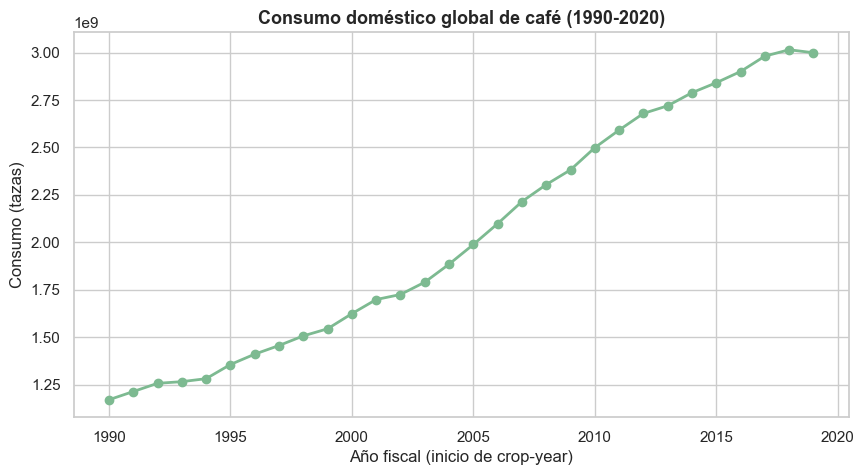

In [5]:
fig, ax = plt.subplots()
viz.plot_global_trend(long_df, ax=ax)
plt.show()

## 4. Top 15 países por consumo doméstico total

Brasil domina ampliamente el consumo doméstico acumulado — es, con diferencia, el mercado doméstico más grande, seguido de Indonesia y Etiopía.

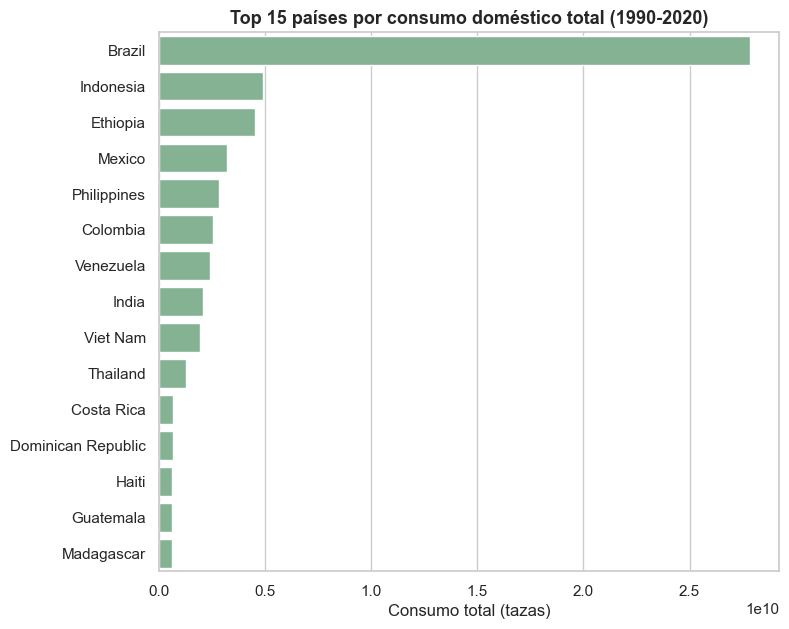

In [6]:
fig, ax = plt.subplots(figsize=(8,7))
viz.plot_top_countries(long_df, ax=ax)
plt.show()

## 5. Heatmap país × año (consumo normalizado)

Cada fila se normaliza a su propio máximo para poder comparar la *forma* de la trayectoria entre países de escalas muy distintas (mercados que despegan tarde vs. mercados maduros desde el inicio de la serie).

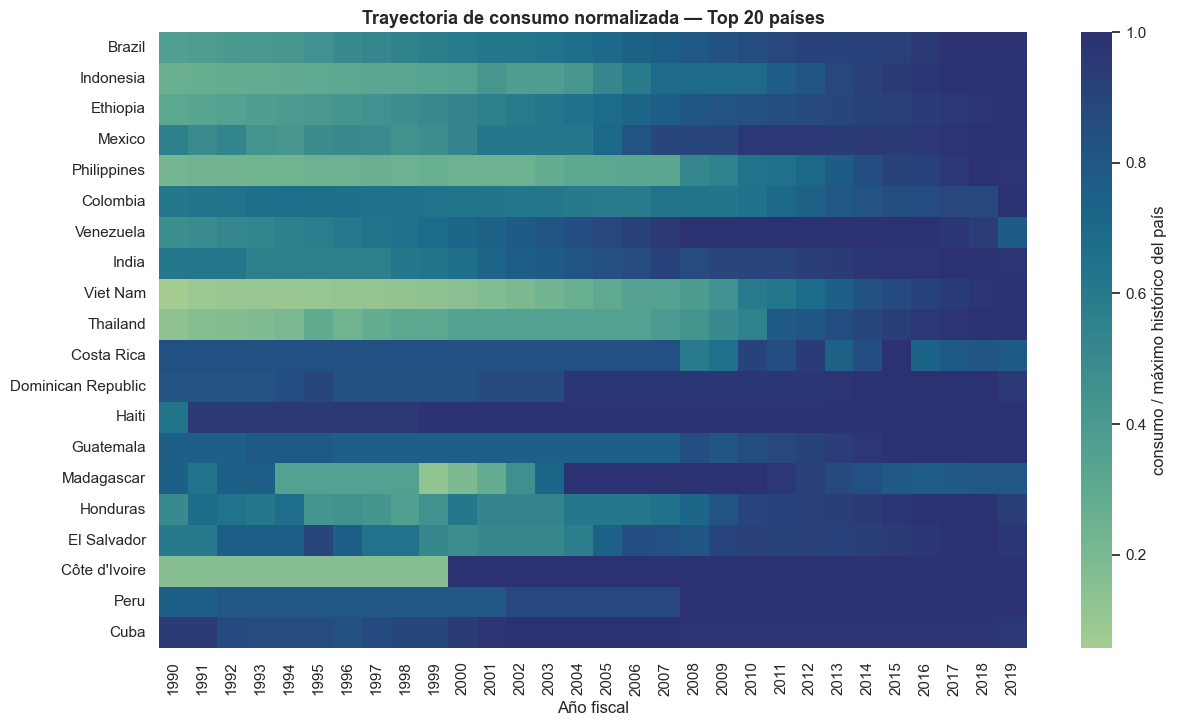

In [7]:
valid = long_df[long_df['is_valid_series']]
top20 = valid.groupby('Country')['consumption'].sum().sort_values(ascending=False).head(20).index
pivot = valid[valid['Country'].isin(top20)].pivot(index='Country', columns='fiscal_year_start', values='consumption')
pivot_norm = pivot.div(pivot.max(axis=1), axis=0)
pivot_norm = pivot_norm.loc[top20]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_norm, cmap='crest', ax=ax, cbar_kws={'label': 'consumo / máximo histórico del país'})
ax.set_title('Trayectoria de consumo normalizada — Top 20 países')
ax.set_xlabel('Año fiscal')
ax.set_ylabel('')
plt.show()

## 6. Insights clave del EDA

1. Dataset limpio, sin nulos, 55 países × 30 crop-years; solo 2 países (Equatorial Guinea, Nepal) tienen serie completa en cero y se excluyen del modelado.
2. El consumo global casi se **triplicó** entre 1990/91 y 2019/20, pero **cayó** en la última campaña — señal a monitorear en el forecast.
3. Brasil concentra una porción muy grande del consumo doméstico mundial (mercado maduro de gran escala); el resto de los top países tienen escalas muy distintas entre sí.
4. El dataset **no incluye precio** — cualquier análisis de "rangos de precio futuro" pedido en el enunciado requeriría una fuente de datos adicional (ver `reports/executive_summary.md`).
5. La heterogeneidad de trayectorias (algunos países crecen sostenidamente, otros se estancan o declinan) motiva el análisis de **clustering** en `03_clustering.ipynb`, y el forecasting por país en `02_forecasting.ipynb`.